# Continuous-time bandpass filter implemented with a discrete-time filter

This notebook solves Exercise 15.8 and visualizes every frequency-domain step. The target equivalent continuous-time response is

$$G(j\omega)=1,\qquad 100\pi<|\omega|<200\pi,$$

and zero elsewhere. The digital filter is

$$H_d(e^{j\Omega})=1,\qquad \Omega_a\le |\Omega|\le \Omega_b,$$

on the principal interval $[-\pi,\pi]$. We use the mapping $\Omega=\omega T_s$ and take the reconstruction period $T_s'=T_s$, so the output frequencies match the input continuous-time frequencies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (11, 7),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
})

## 0. From requested quantities down to the givens

The problem asks us to determine four unknown design quantities:

$$\boxed{W_1^{\min},\qquad T_s^{\max},\qquad \Omega_a,\qquad \Omega_b.}$$

In the diagram below, every downward arrow means: **the quantity above is determined by the equation or known quantity below**. Thus we start from what the problem asks for and keep moving downward until every leaf is a given number from the target passband.

The two numerical leaves supplied directly by the problem are

$$\boxed{\omega_L=100\pi\;\text{rad/s},\qquad \omega_H=200\pi\;\text{rad/s}.}$$

The dependency order is therefore

$$\boxed{(\omega_L,\omega_H)\;\Longrightarrow\;W_1^{\min}\;\Longrightarrow\;T_s^{\max}\;\Longrightarrow\;(\Omega_a,\Omega_b),}$$

although the arrows in the four trees point downward because they answer the reverse question: *what does this requested unknown depend on?*

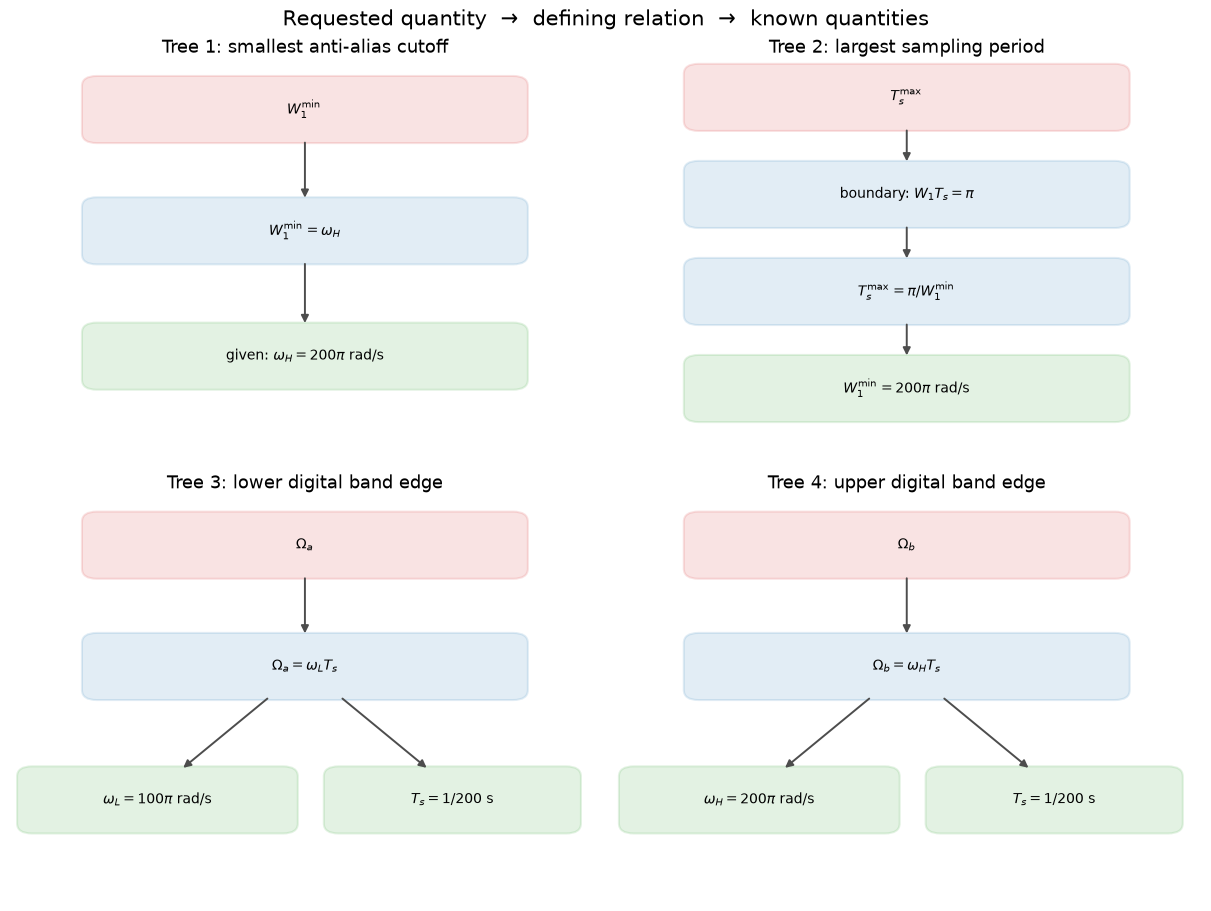

In [2]:
from matplotlib.patches import FancyBboxPatch

def dependency_node(ax, x, y, text, width=0.72, height=0.13, color='C0'):
    box = FancyBboxPatch(
        (x-width/2, y-height/2), width, height,
        boxstyle='round,pad=0.018,rounding_size=0.025',
        facecolor=color, alpha=0.13, edgecolor=color, linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=10)

def dependency_arrow(ax, start, end):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='-|>', lw=1.4, color='0.30'))

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
fig.suptitle('Requested quantity  →  defining relation  →  known quantities', fontsize=15)

# Tree 1: W1_min
ax = axes[0, 0]
dependency_node(ax, .5, .88, r'$W_1^{\min}$', color='C3')
dependency_node(ax, .5, .58, r'$W_1^{\min}=\omega_H$')
dependency_node(ax, .5, .27, r'given: $\omega_H=200\pi$ rad/s', color='C2')
dependency_arrow(ax, (.5, .805), (.5, .655))
dependency_arrow(ax, (.5, .505), (.5, .345))
ax.set_title('Tree 1: smallest anti-alias cutoff')

# Tree 2: Ts_max
ax = axes[0, 1]
dependency_node(ax, .5, .91, r'$T_s^{\max}$', color='C3')
dependency_node(ax, .5, .67, r'boundary: $W_1T_s=\pi$')
dependency_node(ax, .5, .43, r'$T_s^{\max}=\pi/W_1^{\min}$')
dependency_node(ax, .5, .19, r'$W_1^{\min}=200\pi$ rad/s', color='C2')
dependency_arrow(ax, (.5, .835), (.5, .745))
dependency_arrow(ax, (.5, .595), (.5, .505))
dependency_arrow(ax, (.5, .355), (.5, .265))
ax.set_title('Tree 2: largest sampling period')

# Tree 3: Omega_a
ax = axes[1, 0]
dependency_node(ax, .5, .88, r'$\Omega_a$', color='C3')
dependency_node(ax, .5, .58, r'$\Omega_a=\omega_LT_s$')
dependency_node(ax, .25, .25, r'$\omega_L=100\pi$ rad/s', width=.44, color='C2')
dependency_node(ax, .75, .25, r'$T_s=1/200$ s', width=.40, color='C2')
dependency_arrow(ax, (.5, .805), (.5, .655))
dependency_arrow(ax, (.44, .505), (.29, .325))
dependency_arrow(ax, (.56, .505), (.71, .325))
ax.set_title('Tree 3: lower digital band edge')

# Tree 4: Omega_b
ax = axes[1, 1]
dependency_node(ax, .5, .88, r'$\Omega_b$', color='C3')
dependency_node(ax, .5, .58, r'$\Omega_b=\omega_HT_s$')
dependency_node(ax, .25, .25, r'$\omega_H=200\pi$ rad/s', width=.44, color='C2')
dependency_node(ax, .75, .25, r'$T_s=1/200$ s', width=.40, color='C2')
dependency_arrow(ax, (.5, .805), (.5, .655))
dependency_arrow(ax, (.44, .505), (.29, .325))
dependency_arrow(ax, (.56, .505), (.71, .325))
ax.set_title('Tree 4: upper digital band edge')

for ax in axes.flat:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

plt.show()

## 1. Dependency chain

The anti-aliasing filter $H_a(j\omega)$ is low-pass with cutoff $W_1$. It must pass the entire desired band, so its smallest allowed cutoff is the upper band edge:

$$W_1^{\min}=\omega_H=200\pi\;\text{rad/s}.$$

To avoid overlap after sampling, $W_1T_s\le\pi$. The largest sampling period therefore occurs at equality:

$$T_s^{\max}=\frac{\pi}{W_1^{\min}}=\frac1{200}\;\text{s}.$$

Finally, the two analog band edges map to digital frequencies through $\Omega=\omega T_s$:

$$\Omega_a=\omega_LT_s=\frac{\pi}{2},\qquad \Omega_b=\omega_HT_s=\pi.$$

In [3]:
# Given continuous-time band edges (rad/s)
omega_L = 100 * np.pi
omega_H = 200 * np.pi

# Design choices required by the exercise
W1 = omega_H                 # smallest possible anti-alias cutoff
Ts = np.pi / W1             # largest possible sampling period
fs = 1 / Ts                 # sampling frequency in Hz
omega_s = 2 * np.pi / Ts    # sampling angular frequency in rad/s
Omega_a = omega_L * Ts
Omega_b = omega_H * Ts

print(f'W1_min   = {W1:.6f} rad/s = {W1/np.pi:.0f}π rad/s')
print(f'Ts_max   = {Ts:.6f} s = 1/{1/Ts:.0f} s')
print(f'fs       = {fs:.1f} Hz')
print(f'omega_s  = {omega_s:.6f} rad/s = {omega_s/np.pi:.0f}π rad/s')
print(f'Omega_a  = {Omega_a:.6f} rad = {Omega_a/np.pi:.2f}π')
print(f'Omega_b  = {Omega_b:.6f} rad = {Omega_b/np.pi:.2f}π')

assert np.isclose(W1, 200*np.pi)
assert np.isclose(Ts, 1/200)
assert np.isclose(Omega_a, np.pi/2)
assert np.isclose(Omega_b, np.pi)

W1_min   = 628.318531 rad/s = 200π rad/s
Ts_max   = 0.005000 s = 1/200 s
fs       = 200.0 Hz
omega_s  = 1256.637061 rad/s = 400π rad/s
Omega_a  = 1.570796 rad = 0.50π
Omega_b  = 3.141593 rad = 1.00π


## 2. Numerical summary

| Requested variable | Dependency | Result |
|---|---|---|
| $W_1^{\min}$ | $W_1^{\min}=\omega_H$ | $200\pi$ rad/s |
| $T_s^{\max}$ | $T_s^{\max}=\pi/W_1$ | $1/200$ s |
| $\Omega_a$ | $\Omega_a=\omega_LT_s$ | $\pi/2$ |
| $\Omega_b$ | $\Omega_b=\omega_HT_s$ | $\pi$ |

Notice that $f_s=200$ Hz, while the positive analog passband is 50–100 Hz. Thus its upper edge lands exactly at the Nyquist frequency, 100 Hz. This is the limiting ideal-filter case requested by the exercise.

<>:25: SyntaxWarning: invalid escape sequence '\o'
<>:26: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:39: SyntaxWarning: invalid escape sequence '\O'
<>:40: SyntaxWarning: invalid escape sequence '\O'
<>:45: SyntaxWarning: invalid escape sequence '\O'
<>:46: SyntaxWarning: invalid escape sequence '\o'
<>:25: SyntaxWarning: invalid escape sequence '\o'
<>:26: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:39: SyntaxWarning: invalid escape sequence '\O'
<>:40: SyntaxWarning: invalid escape sequence '\O'
<>:45: SyntaxWarning: invalid escape sequence '\O'
<>:46: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_41094/884269829.py:25: SyntaxWarning: invalid escape sequence '\o'
  axes[0, 0].set(title='Target continuous-time response $G(j\omega)$',
/tmp/ipykernel_41094/884269829.

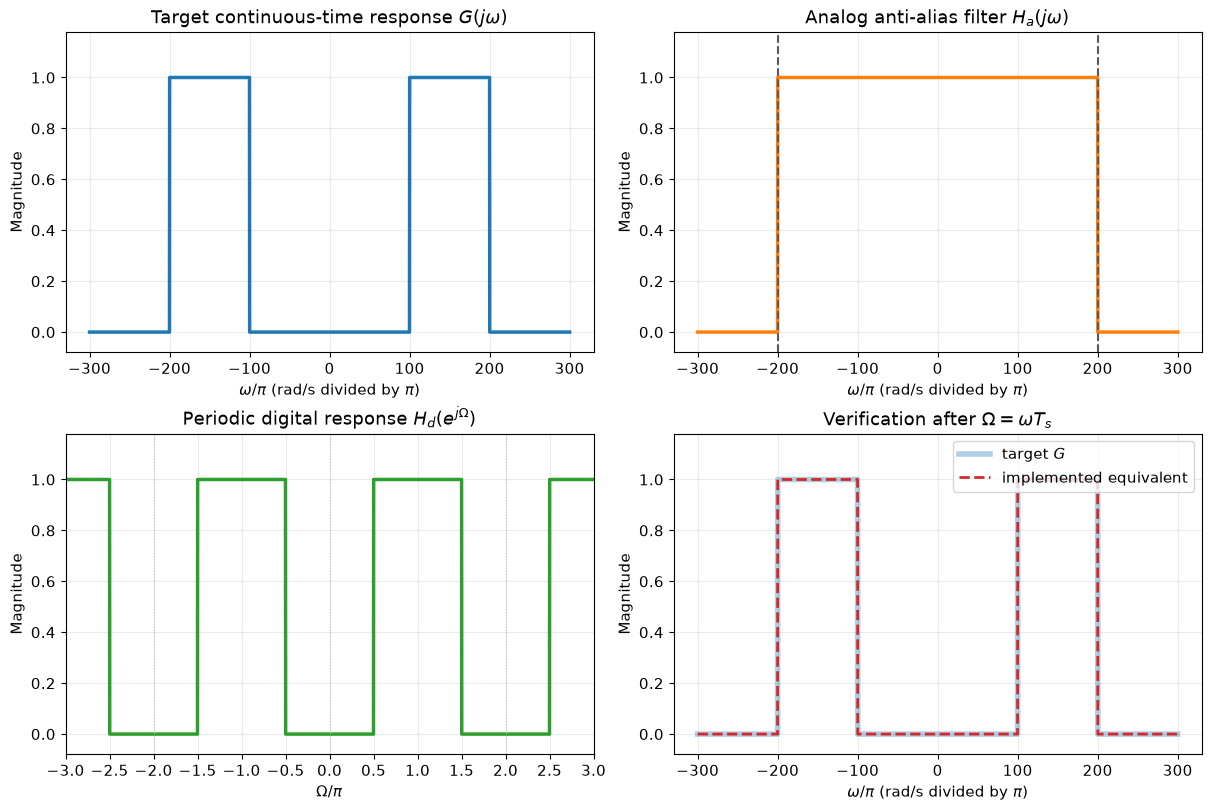

In [4]:
def ideal_target_G(omega, omega_L, omega_H):
    return ((np.abs(omega) > omega_L) & (np.abs(omega) < omega_H)).astype(float)

def ideal_antialias_Ha(omega, W1):
    return (np.abs(omega) <= W1).astype(float)

def wrap_to_pi(Omega):
    return (Omega + np.pi) % (2*np.pi) - np.pi

def ideal_digital_Hd(Omega, Omega_a, Omega_b):
    Om = np.abs(wrap_to_pi(Omega))
    return ((Om >= Omega_a) & (Om <= Omega_b)).astype(float)

omega = np.linspace(-300*np.pi, 300*np.pi, 6001)
Omega = np.linspace(-3*np.pi, 3*np.pi, 6001)

G = ideal_target_G(omega, omega_L, omega_H)
Ha = ideal_antialias_Ha(omega, W1)
Hd = ideal_digital_Hd(Omega, Omega_a, Omega_b)
G_equiv = ideal_antialias_Ha(omega, W1) * ideal_digital_Hd(omega*Ts, Omega_a, Omega_b)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].plot(omega/np.pi, G, lw=2.5, color='C0')
axes[0, 0].set(title='Target continuous-time response $G(j\omega)$',
               xlabel='$\omega/\pi$ (rad/s divided by $\pi$)', ylabel='Magnitude', ylim=(-0.08, 1.18))
axes[0, 0].set_xticks([-300, -200, -100, 0, 100, 200, 300])

axes[0, 1].plot(omega/np.pi, Ha, lw=2.5, color='C1')
axes[0, 1].axvline(-W1/np.pi, ls='--', color='0.35')
axes[0, 1].axvline(W1/np.pi, ls='--', color='0.35')
axes[0, 1].set(title='Analog anti-alias filter $H_a(j\omega)$',
               xlabel='$\omega/\pi$ (rad/s divided by $\pi$)', ylabel='Magnitude', ylim=(-0.08, 1.18))
axes[0, 1].set_xticks([-300, -200, -100, 0, 100, 200, 300])

axes[1, 0].plot(Omega/np.pi, Hd, lw=2.5, color='C2')
for k in range(-3, 4):
    axes[1, 0].axvline(2*k, color='0.75', lw=0.8, ls=':')
axes[1, 0].set(title='Periodic digital response $H_d(e^{j\Omega})$',
               xlabel='$\Omega/\pi$', ylabel='Magnitude', ylim=(-0.08, 1.18), xlim=(-3, 3))
axes[1, 0].set_xticks(np.arange(-3, 3.1, 0.5))

axes[1, 1].plot(omega/np.pi, G, lw=4, alpha=0.35, label='target $G$')
axes[1, 1].plot(omega/np.pi, G_equiv, '--', lw=2, color='C3', label='implemented equivalent')
axes[1, 1].set(title='Verification after $\Omega=\omega T_s$',
               xlabel='$\omega/\pi$ (rad/s divided by $\pi$)', ylabel='Magnitude', ylim=(-0.08, 1.18))
axes[1, 1].set_xticks([-300, -200, -100, 0, 100, 200, 300])
axes[1, 1].legend(loc='upper right')

plt.show()

## 3. Why the anti-alias filter is essential

Because $H_d(e^{j\Omega})$ is $2\pi$-periodic, substituting $\Omega=\omega T_s$ repeats its bands every

$$\omega_s=\frac{2\pi}{T_s}=400\pi\;\text{rad/s}.$$

The digital filter alone would therefore also pass unwanted analog-frequency images. Multiplication by the analog low-pass $H_a(j\omega)$ keeps only the central interval $|\omega|\le200\pi$ and removes those images.

<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_41094/1833264651.py:7: SyntaxWarning: invalid escape sequence '\o'
  ax.plot(omega_images/np.pi, Hd_mapped, lw=2, label='$H_d(e^{j\omega T_s})$: repeated analog bands')
/tmp/ipykernel_41094/1833264651.py:8: SyntaxWarning: invalid escape sequence '\o'
  ax.fill_between(omega_images/np.pi, 0, Ha_images, color='C1', alpha=0.15, label='$H_a(j\omega)$ retained region')
/tmp/ipykernel_41094/1833264651.py:12: SyntaxWarning: invalid escape sequence '\o'
  ax.set(xlabel='$\omega/\pi$ (rad/s divided by $\pi$)', ylabel='Magnitude',


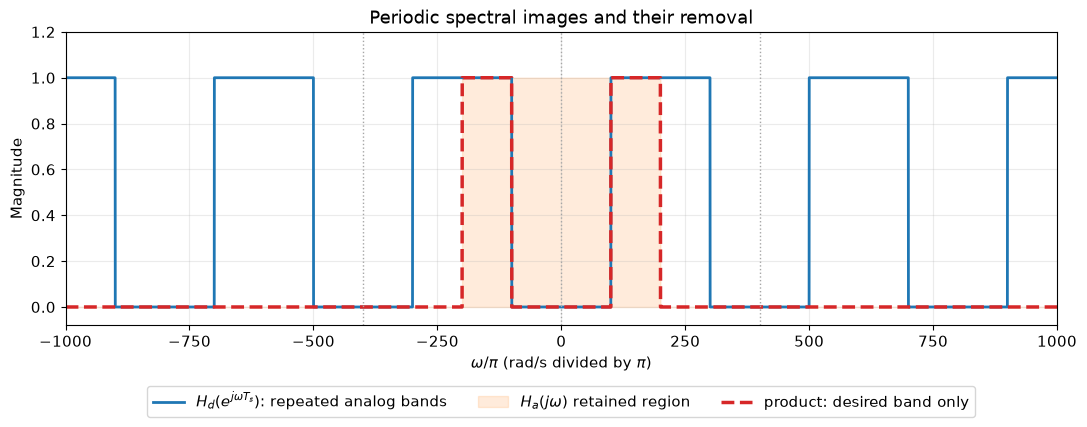

In [5]:
# Sample the full displayed range so repeated spectral images are visible.
omega_images = np.linspace(-1000*np.pi, 1000*np.pi, 20001)
Ha_images = ideal_antialias_Ha(omega_images, W1)
Hd_mapped = ideal_digital_Hd(omega_images*Ts, Omega_a, Omega_b)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(omega_images/np.pi, Hd_mapped, lw=2, label='$H_d(e^{j\omega T_s})$: repeated analog bands')
ax.fill_between(omega_images/np.pi, 0, Ha_images, color='C1', alpha=0.15, label='$H_a(j\omega)$ retained region')
ax.plot(omega_images/np.pi, Hd_mapped*Ha_images, '--', lw=2.5, color='C3', label='product: desired band only')
for k in [-1, 0, 1]:
    ax.axvline(k*omega_s/np.pi, color='0.65', ls=':', lw=1)
ax.set(xlabel='$\omega/\pi$ (rad/s divided by $\pi$)', ylabel='Magnitude',
       title='Periodic spectral images and their removal', xlim=(-1000, 1000), ylim=(-0.08, 1.2))
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()
plt.show()

## 4. Reusable calculator

Change the two band edges below to reuse the same ideal limiting design. The inputs are in rad/s.

In [6]:
def limiting_bandpass_design(omega_L, omega_H):
    if not (0 < omega_L < omega_H):
        raise ValueError('Require 0 < omega_L < omega_H.')
    W1_min = omega_H
    Ts_max = np.pi / W1_min
    return {
        'W1_min_rad_s': W1_min,
        'Ts_max_s': Ts_max,
        'fs_min_Hz': 1/Ts_max,
        'Omega_a_rad': omega_L*Ts_max,
        'Omega_b_rad': omega_H*Ts_max,
    }

limiting_bandpass_design(100*np.pi, 200*np.pi)

{'W1_min_rad_s': 628.3185307179587,
 'Ts_max_s': 0.005,
 'fs_min_Hz': 200.0,
 'Omega_a_rad': 1.5707963267948966,
 'Omega_b_rad': 3.141592653589793}

## 5. General step-by-step LaTeX solver

The function below accepts **any valid lower and upper band edges for this same system topology**. The input can be in either `rad/s` or `Hz`. It then renders every logical step as LaTeX, returns all computed quantities as a dictionary, checks the Nyquist mapping, and draws the resulting analog and digital spectra.

Use it as follows:

```python
result = solve_bandpass_latex(100*np.pi, 200*np.pi, unit='rad/s')
```

or equivalently

```python
result = solve_bandpass_latex(50, 100, unit='Hz')
```

Both calls describe the same target passband.

In [7]:
from fractions import Fraction

try:
    from IPython.display import display, Math, Markdown
    _RICH_LATEX = True
except ImportError:
    _RICH_LATEX = False

def _fraction_latex(frac):
    if frac.denominator == 1:
        return str(frac.numerator)
    return rf'\frac{{{frac.numerator}}}{{{frac.denominator}}}'

def _real_latex(value, max_denominator=100000):
    value = float(value)
    frac = Fraction(value).limit_denominator(max_denominator)
    if np.isclose(value, float(frac), rtol=1e-11, atol=1e-12):
        return _fraction_latex(frac)
    return f'{value:.8g}'

def _pi_latex(value, max_denominator=10000):
    value = float(value)
    ratio = value / np.pi
    frac = Fraction(ratio).limit_denominator(max_denominator)
    if not np.isclose(ratio, float(frac), rtol=1e-11, atol=1e-12):
        return f'{value:.8g}'
    n, d = frac.numerator, frac.denominator
    if n == 0:
        return '0'
    sign = '-' if n < 0 else ''
    n = abs(n)
    numerator = r'\pi' if n == 1 else rf'{n}\pi'
    return sign + numerator if d == 1 else sign + rf'\frac{{{numerator}}}{{{d}}}'

def _show_step(number, title, latex):
    if _RICH_LATEX:
        display(Markdown(f'### Step {number}: {title}'))
        display(Math(latex))
    else:
        print(f'\nStep {number}: {title}')
        print('$$' + latex + '$$')

def solve_bandpass_latex(lower, upper, unit='rad/s', make_plot=True):
    """
    Solve the ideal CT/DT bandpass design step by step.

    Parameters
    ----------
    lower, upper : positive numbers
        Positive-frequency passband edges.
    unit : {'rad/s', 'Hz'}
        Unit used for lower and upper.
    make_plot : bool
        Draw the analog and digital frequency responses.

    Returns
    -------
    dict
        omega_L, omega_H, W1_min, Ts_max, fs_min, Omega_a, Omega_b.
    """
    lower = float(lower)
    upper = float(upper)
    if not np.isfinite(lower) or not np.isfinite(upper):
        raise ValueError('Band edges must be finite numbers.')
    if lower <= 0 or upper <= lower:
        raise ValueError('Require 0 < lower < upper.')
    if unit not in {'rad/s', 'Hz'}:
        raise ValueError("unit must be either 'rad/s' or 'Hz'.")

    if unit == 'Hz':
        omega_L = 2*np.pi*lower
        omega_H = 2*np.pi*upper
        _show_step(1, 'Convert the supplied edges to angular frequency',
                   rf'\omega_L=2\pi({lower:g})={_pi_latex(omega_L)},\qquad '
                   rf'\omega_H=2\pi({upper:g})={_pi_latex(omega_H)}\;\mathrm{{rad/s}}')
        next_step = 2
    else:
        omega_L, omega_H = lower, upper
        _show_step(1, 'Read the target continuous-time passband',
                   rf'G(j\omega)=1\quad\mathrm{{for}}\quad '
                   rf'{_pi_latex(omega_L)}<|\omega|<{_pi_latex(omega_H)}')
        next_step = 2

    W1_min = omega_H
    _show_step(next_step, 'Choose the smallest anti-alias cutoff that passes the whole band',
               rf'W_1\ge\omega_H\quad\Longrightarrow\quad '
               rf'W_1^{{\min}}=\omega_H={_pi_latex(W1_min)}\;\mathrm{{rad/s}}')

    _show_step(next_step+1, 'Write the no-aliasing constraint',
               r'W_1T_s\le\pi')

    Ts_max = np.pi / W1_min
    _show_step(next_step+2, 'Maximize the sampling period by using equality',
               rf'T_s^{{\max}}=\frac{{\pi}}{{W_1^{{\min}}}}'
               rf'=\frac{{\pi}}{{{_pi_latex(W1_min)}}}'
               rf'={_real_latex(Ts_max)}\;\mathrm{{s}}')

    fs_min = 1/Ts_max
    _show_step(next_step+3, 'Convert the sampling period to sampling frequency',
               rf'f_s^{{\min}}=\frac{{1}}{{T_s^{{\max}}}}'
               rf'={_real_latex(fs_min)}\;\mathrm{{Hz}}')

    Omega_a = omega_L*Ts_max
    _show_step(next_step+4, 'Map the lower band edge into digital frequency',
               rf'\Omega_a=\omega_LT_s^{{\max}}'
               rf'=({_pi_latex(omega_L)})({_real_latex(Ts_max)})'
               rf'={_pi_latex(Omega_a)}\;\mathrm{{rad/sample}}')

    Omega_b = omega_H*Ts_max
    _show_step(next_step+5, 'Map the upper band edge into digital frequency',
               rf'\Omega_b=\omega_HT_s^{{\max}}'
               rf'=({_pi_latex(omega_H)})({_real_latex(Ts_max)})'
               rf'={_pi_latex(Omega_b)}\;\mathrm{{rad/sample}}')

    _show_step(next_step+6, 'Collect the final design',
               rf'\boxed{{W_1={_pi_latex(W1_min)}\;\mathrm{{rad/s}},\quad '
               rf'T_s={_real_latex(Ts_max)}\;\mathrm{{s}},\quad '
               rf'\Omega_a={_pi_latex(Omega_a)},\quad\Omega_b={_pi_latex(Omega_b)}}}')

    assert Omega_a > 0
    assert Omega_a < Omega_b
    assert np.isclose(Omega_b, np.pi)
    assert np.isclose(W1_min*Ts_max, np.pi)

    result = {
        'omega_L_rad_s': omega_L,
        'omega_H_rad_s': omega_H,
        'W1_min_rad_s': W1_min,
        'Ts_max_s': Ts_max,
        'fs_min_Hz': fs_min,
        'Omega_a_rad_sample': Omega_a,
        'Omega_b_rad_sample': Omega_b,
    }

    if make_plot:
        w = np.linspace(-1.35*omega_H, 1.35*omega_H, 5001)
        Om = np.linspace(-np.pi, np.pi, 5001)
        analog = ((np.abs(w) >= omega_L) & (np.abs(w) <= omega_H)).astype(float)
        digital = ((np.abs(Om) >= Omega_a) & (np.abs(Om) <= Omega_b)).astype(float)
        fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
        ax[0].plot(w/np.pi, analog, lw=2.5)
        ax[0].axvline(omega_L/np.pi, ls=':', color='0.45')
        ax[0].axvline(omega_H/np.pi, ls=':', color='0.45')
        ax[0].axvline(-omega_L/np.pi, ls=':', color='0.45')
        ax[0].axvline(-omega_H/np.pi, ls=':', color='0.45')
        ax[0].set(title='Requested continuous-time passband',
                  xlabel=r'$\omega/\pi$', ylabel='Magnitude', ylim=(-.08, 1.18))
        ax[1].plot(Om/np.pi, digital, lw=2.5, color='C2')
        ax[1].axvline(Omega_a/np.pi, ls=':', color='0.45')
        ax[1].axvline(-Omega_a/np.pi, ls=':', color='0.45')
        ax[1].set(title='Automatically mapped digital passband',
                  xlabel=r'$\Omega/\pi$', ylabel='Magnitude',
                  xlim=(-1, 1), ylim=(-.08, 1.18))
        plt.show()

    return result

### Step 1: Read the target continuous-time passband

<IPython.core.display.Math object>

### Step 2: Choose the smallest anti-alias cutoff that passes the whole band

<IPython.core.display.Math object>

### Step 3: Write the no-aliasing constraint

...

<IPython.core.display.Math object>

### Step 7: Map the upper band edge into digital frequency

<IPython.core.display.Math object>

### Step 8: Collect the final design

<IPython.core.display.Math object>

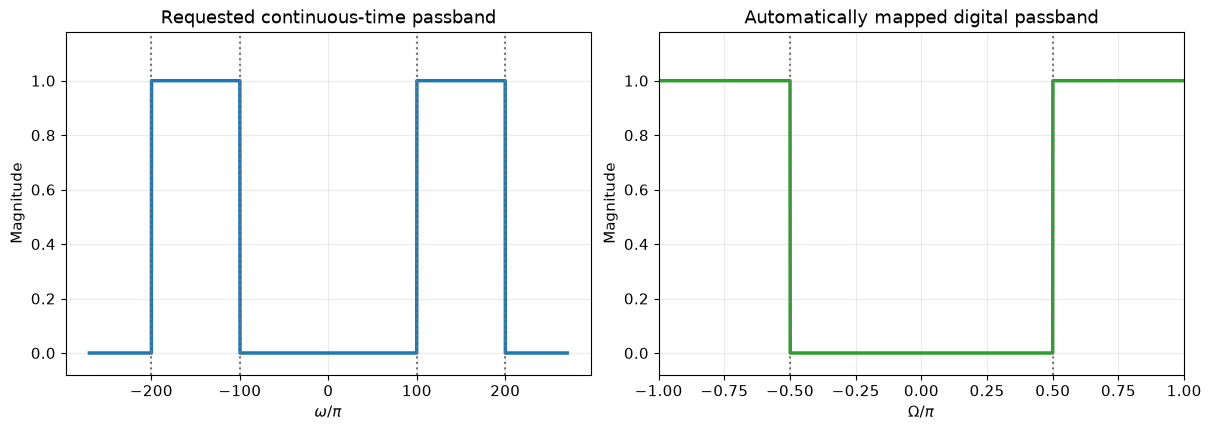

{'omega_L_rad_s': 314.1592653589793,
 'omega_H_rad_s': 628.3185307179587,
 'W1_min_rad_s': 628.3185307179587,
 'Ts_max_s': 0.005,
 'fs_min_Hz': 200.0,
 'Omega_a_rad_sample': 1.5707963267948966,
 'Omega_b_rad_sample': 3.141592653589793}

In [8]:
# EDIT ONLY THESE THREE INPUTS, then run this cell.
lower_edge = 100*np.pi
upper_edge = 200*np.pi
input_unit = 'rad/s'       # change to 'Hz' when entering ordinary frequencies

result = solve_bandpass_latex(
    lower_edge,
    upper_edge,
    unit=input_unit,
    make_plot=True,
)
result

## Final answer

$$\boxed{W_1=200\pi\;\text{rad/s},\quad T_s=\frac1{200}\;\text{s},\quad \Omega_a=\frac\pi2,\quad \Omega_b=\pi.}$$

These are ideal boundary values. A realizable anti-aliasing filter needs a transition band, so an engineering design would normally sample somewhat faster than 200 Hz rather than place the passband edge exactly at Nyquist.